# MLP Regressor aplicado ao preço de abertura da Microsoft

Alvo: `Open` (preço de abertura diário da ação MSFT).

Uma rede neural do tipo MLP (Multilayer Perceptron) para regressão funciona assim: as variáveis
de entrada passam por camadas ocultas que aplicam combinações lineares seguidas de uma função
de ativação não linear, e a camada de saída é uma função linear simples que devolve um número
contínuo. É essa composição de camadas que permite à rede capturar relações não lineares entre
as variáveis explicativas e o alvo, algo que uma regressão linear não consegue.

Roteiro do notebook:

| seção | conteúdo |
|---|---|
| 0 | dependências |
| 1 | carga da base e definição do alvo |
| 2 | construção das variáveis de entrada |
| 3 | alvo, split e escalonamento |
| 4 | arquitetura da rede |
| 5 | early stopping |
| 6 | treino e previsões |
| 7 | métricas de avaliação |
| 8 | curva de aprendizado: treino contra validação |
| 9 | real contra previsto |
| 10 | resíduos e histograma |
| 11 | importância das variáveis |
| 12 | conclusões |

## 0. Dependências

O material da aula usa `tensorflow.keras` (`Sequential`, `Dense`, `EarlyStopping`). Aqui a rede
é construída com `sklearn.neural_network.MLPRegressor`, que implementa exatamente o mesmo objeto
matemático: camadas densas totalmente conectadas, ativação ReLU nas camadas ocultas, saída linear
e otimizador Adam. A correspondência é direta:

| aula (Keras) | aqui (scikit-learn) |
|---|---|
| `Dense(64, activation="relu")` duas vezes | `hidden_layer_sizes=(64, 64)`, `activation="relu"` |
| `Dense(1, activation="linear")` | saída linear implícita do `MLPRegressor` |
| `optimizer="adam"` | `solver="adam"` |
| `epochs=2000`, `batch_size=32` | `max_iter=2000`, `batch_size=32` |
| `validation_split=0.15` | `validation_fraction=0.15` |
| `EarlyStopping(patience=20, restore_best_weights=True)` | `early_stopping=True`, `n_iter_no_change=20` |

A única diferença é a função de perda: a aula treina com MAE, e o `MLPRegressor` treina com erro
quadrático. O MAE continua sendo reportado como métrica de avaliação, que é o uso principal dele
no material.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEMENTE = 42
print("ambiente pronto")

ambiente pronto


## 1. Carga da base e definição do alvo

A base é a mesma usada nos outros três notebooks (Holt-Winters, SARIMAX e Random Forest), o que
permite comparar os quatro modelos em condições idênticas ao final do trabalho.

In [2]:
CAMINHO = "Microsoft_Stock.csv"

df = pd.read_csv(CAMINHO)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M:%S")
df = df.sort_values("Date").set_index("Date")

print(f"pregões : {len(df)}")
print(f"período : {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")
print(f"colunas : {list(df.columns)}")
print(f"faltantes: {int(df.isna().sum().sum())}")
df.head()

pregões : 1511
período : 2015-04-01 a 2021-03-31
colunas : ['Open', 'High', 'Low', 'Close', 'Volume']
faltantes: 0


,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01 16:00:00,40.6000,40.7600,40.3100,40.7200,36865322
2015-04-02 16:00:00,40.6600,40.7400,40.1200,40.2900,37487476
2015-04-06 16:00:00,40.3400,41.7800,40.1800,41.5500,39223692
2015-04-07 16:00:00,41.6100,41.9100,41.3100,41.5300,28809375
2015-04-08 16:00:00,41.4800,41.6900,41.0400,41.4200,24753438


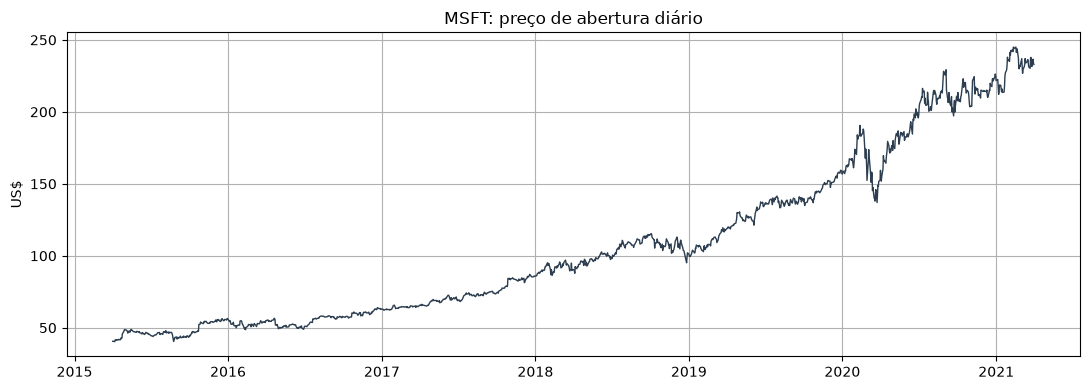

mínimo : US$ 40.34
máximo : US$ 245.03
média  : US$ 107.39


In [3]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Open"], color="#2c3e50", lw=1)
ax.set_title("MSFT: preço de abertura diário")
ax.set_ylabel("US$")
plt.tight_layout()
plt.show()

print(f"mínimo : US$ {df['Open'].min():,.2f}")
print(f"máximo : US$ {df['Open'].max():,.2f}")
print(f"média  : US$ {df['Open'].mean():,.2f}")

## 2. Construção das variáveis de entrada

No exemplo da aula a base já vinha com as colunas prontas (quartos, área, idade do imóvel) e
bastava separar o alvo das demais. Numa série de preços isso não existe: as colunas `High`,
`Low`, `Close` e `Volume` do mesmo dia só são conhecidas depois do pregão, então usá-las para
prever a abertura daquele dia seria vazamento de informação.

A solução é defasar tudo em um dia. Toda variável abaixo termina em `_lag1` e descreve o pregão
anterior, ou seja, é informação disponível antes da abertura de hoje. O conjunto é idêntico ao
usado no notebook de Random Forest, de propósito, para que a comparação entre os dois modelos
isole o efeito do algoritmo e não o das variáveis.

| variável | o que descreve |
|---|---|
| `open_lag1`, `close_lag1`, `high_lag1`, `low_lag1` | nível de preço do dia anterior |
| `ret_lag1` | retorno percentual do dia anterior |
| `range_lag1` | amplitude High menos Low do dia anterior |
| `vol5_lag1` | volatilidade dos últimos 5 pregões |
| `logvol_lag1` | log do volume negociado |
| `ma5_lag1`, `ma20_lag1` | médias móveis de 5 e 20 pregões |
| `dow` | dia da semana da abertura |

In [4]:
base = pd.DataFrame(index=df.index)
base["y"] = df["Open"]

base["open_lag1"]   = df["Open"].shift(1)
base["close_lag1"]  = df["Close"].shift(1)
base["high_lag1"]   = df["High"].shift(1)
base["low_lag1"]    = df["Low"].shift(1)
base["ret_lag1"]    = df["Close"].pct_change().shift(1)
base["range_lag1"]  = (df["High"] - df["Low"]).shift(1)
base["vol5_lag1"]   = df["Close"].pct_change().rolling(5).std().shift(1)
base["logvol_lag1"] = np.log(df["Volume"]).shift(1)
base["ma5_lag1"]    = df["Close"].rolling(5).mean().shift(1)
base["ma20_lag1"]   = df["Close"].rolling(20).mean().shift(1)
base["dow"]         = base.index.dayofweek

base = base.dropna()
FEATURES = [c for c in base.columns if c != "y"]

print(f"linhas após limpeza : {len(base)}")
print(f"variáveis de entrada: {len(FEATURES)}")
base.head(3)

linhas após limpeza : 1491
variáveis de entrada: 11


,y,open_lag1,close_lag1,high_lag1,low_lag1,ret_lag1,range_lag1,vol5_lag1,logvol_lag1,ma5_lag1,ma20_lag1,dow
Date,,,,,,,,,,,,
2015-04-30 16:00:00,48.7000,48.7200,49.0600,49.3100,48.5000,-0.0020,0.8100,0.0441,17.6826,47.4920,43.2080,3
2015-05-01 16:00:00,48.5800,48.7000,48.6400,49.5400,48.6000,-0.0086,0.9400,0.0465,17.9857,48.5520,43.6040,4
2015-05-04 16:00:00,48.3700,48.5800,48.6600,48.8800,48.4000,0.0004,0.4800,0.0121,17.4775,48.7100,44.0225,0


## 3. Alvo, split e escalonamento

Três decisões precisam ser justificadas aqui, porque todas se afastam do código literal da aula.

Primeira: o alvo. Na aula o alvo é o preço do imóvel, um nível. Aqui o alvo é a variação
`Open de hoje menos Close de ontem`, e não o preço em si. O motivo aparece no gráfico abaixo:
o nível tem tendência de alta forte e o teste cobre preços que nunca foram vistos no treino,
enquanto a variação oscila em torno de zero e tem a mesma faixa nos dois períodos. Uma rede
treinada em preços entre 40 e 167 dólares não tem como aprender a prever 245. Treinando na
variação, a previsão final é reconstruída somando `close_lag1` de volta.

Segunda: o split. A aula usa `train_test_split(..., random_state=42)`, que embaralha as linhas.
Em série temporal isso coloca dias futuros dentro do treino e inflaciona artificialmente o
resultado. O corte aqui é cronológico: os primeiros 80 por cento dos pregões são treino e os
últimos 20 por cento são teste.

Terceira: o escalonamento. Essa parte segue a aula sem mudança. O `StandardScaler` é ajustado
apenas no treino e depois aplicado ao teste, nunca o contrário. Em rede neural o escalonamento
não é opcional: as variáveis vão de ordens de grandeza muito diferentes (`logvol_lag1` perto de
17, `ret_lag1` perto de 0.001) e sem padronizar o gradiente fica dominado pelas colunas de maior
escala.

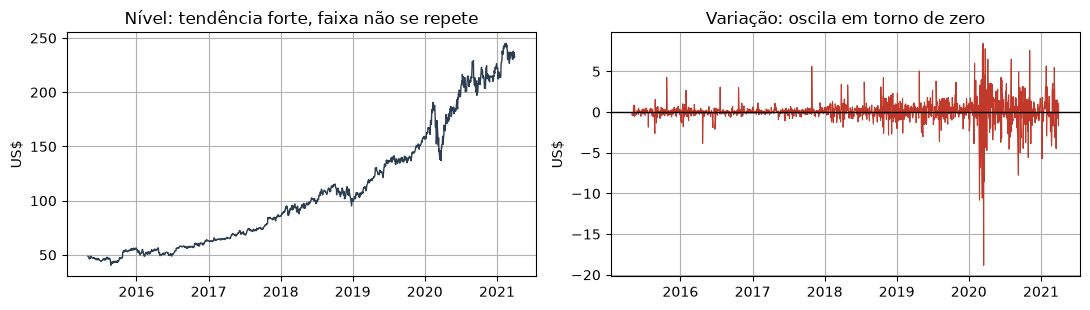

In [5]:
base["alvo"] = base["y"] - base["close_lag1"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(base.index, base["y"], color="#2c3e50", lw=1)
axes[0].set_title("Nível: tendência forte, faixa não se repete")
axes[0].set_ylabel("US$")
axes[1].plot(base.index, base["alvo"], color="#c0392b", lw=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Variação: oscila em torno de zero")
axes[1].set_ylabel("US$")
plt.tight_layout()
plt.show()

In [6]:
corte = int(len(base) * 0.8)
treino, teste = base.iloc[:corte], base.iloc[corte:]

X_train = treino[FEATURES]
X_test  = teste[FEATURES]
y_train = treino["alvo"].astype(float)
y_test  = teste["alvo"].astype(float)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"treino : {len(treino)} dias | {treino.index.min():%Y-%m-%d} a {treino.index.max():%Y-%m-%d}")
print(f"teste  : {len(teste)} dias | {teste.index.min():%Y-%m-%d} a {teste.index.max():%Y-%m-%d}")
print()
print(f"preço no treino  : US$ {treino['y'].min():,.2f} a US$ {treino['y'].max():,.2f}")
print(f"preço no teste   : US$ {teste['y'].min():,.2f} a US$ {teste['y'].max():,.2f}")
print(f"variação treino  : US$ {y_train.min():,.2f} a US$ {y_train.max():,.2f}")
print(f"variação teste   : US$ {y_test.min():,.2f} a US$ {y_test.max():,.2f}")

treino : 1192 dias | 2015-04-30 a 2020-01-23
teste  : 299 dias | 2020-01-24 a 2021-03-31

preço no treino  : US$ 40.45 a US$ 167.42
preço no teste   : US$ 137.01 a US$ 245.03
variação treino  : US$ -3.87 a US$ 5.61
variação teste   : US$ -18.83 a US$ 8.44


In [7]:
antes = pd.DataFrame(X_train).describe().T[["mean", "std"]]
depois = pd.DataFrame(X_train_s, columns=FEATURES).describe().T[["mean", "std"]]
comparacao_escala = antes.join(depois, lsuffix=" (antes)", rsuffix=" (depois)")
comparacao_escala

,mean (antes),std (antes),mean (depois),std (depois)
open_lag1,84.5384,32.4810,0.0000,1.0004
close_lag1,84.5505,32.4642,0.0000,1.0004
high_lag1,85.2045,32.6751,-0.0000,1.0004
low_lag1,83.8026,32.1994,0.0000,1.0004
ret_lag1,0.0011,0.0142,0.0000,1.0004
range_lag1,1.4019,0.9754,0.0000,1.0004
vol5_lag1,0.0123,0.0080,-0.0000,1.0004
logvol_lag1,17.0795,0.4097,0.0000,1.0004
ma5_lag1,84.3520,32.3087,-0.0000,1.0004
ma20_lag1,83.6034,31.8402,0.0000,1.0004


## 4. Arquitetura da rede

A aula sugere duas camadas ocultas de 64 neurônios com ativação ReLU e uma saída linear de um
neurônio. Mantenho essa arquitetura.

Por que ela faz sentido aqui: com 11 variáveis de entrada, duas camadas de 64 dão capacidade
suficiente para capturar interações não lineares (por exemplo, o efeito da volatilidade mudar
conforme o volume negociado) sem explodir o número de parâmetros diante de pouco mais de mil
observações de treino. A saída precisa ser linear porque o alvo é um número contínuo que pode
ser negativo, então nenhuma ativação que restrinja o sinal serviria.

O `alpha` é a regularização L2 dos pesos, usada para segurar o overfitting num conjunto de treino
pequeno.

In [8]:
n_features = X_train_s.shape[1]
print(f"entradas da rede: {n_features}")

modelo = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=2000,
    random_state=SEMENTE,
)

arquitetura = pd.DataFrame(
    [
        ["entrada", n_features, "-"],
        ["oculta 1", 64, "relu"],
        ["oculta 2", 64, "relu"],
        ["saida", 1, "linear"],
    ],
    columns=["camada", "neuronios", "ativacao"],
)
arquitetura

entradas da rede: 11


,camada,neuronios,ativacao
0,entrada,11,-
1,oculta 1,64,relu
2,oculta 2,64,relu
3,saida,1,linear


## 5. Early stopping

Early stopping interrompe o treino quando a métrica acompanhada no conjunto de validação para de
melhorar por um número definido de épocas. Serve para dois propósitos: evitar overfitting, porque
a partir de certo ponto a rede passa a decorar o treino e piorar na validação, e economizar tempo,
porque não faz sentido rodar 2000 épocas se o ganho cessou na época 300.

Os três parâmetros descritos na aula aparecem aqui com o nome do scikit-learn:

| aula | aqui | papel |
|---|---|---|
| `monitor="val_loss"` | `early_stopping=True` | separa uma parcela do treino para validar |
| `validation_split=0.15` | `validation_fraction=0.15` | tamanho dessa parcela |
| `patience=20` | `n_iter_no_change=20` | tolera 20 épocas seguidas sem melhora |
| `restore_best_weights=True` | comportamento padrão do `MLPRegressor` | devolve os pesos da melhor época |

Uma observação importante sobre a parcela de validação: o `MLPRegressor` separa os últimos
15 por cento do conjunto de treino, respeitando a ordem em que as linhas foram passadas. Como o
treino aqui está em ordem cronológica, a validação cai no período imediatamente anterior ao teste,
que é exatamente o que se quer numa série temporal.

In [9]:
modelo.set_params(early_stopping=True, validation_fraction=0.15, n_iter_no_change=20)

parametros = pd.Series(
    {
        "early_stopping": modelo.early_stopping,
        "validation_fraction": modelo.validation_fraction,
        "n_iter_no_change": modelo.n_iter_no_change,
        "max_iter": modelo.max_iter,
        "batch_size": modelo.batch_size,
        "solver": modelo.solver,
        "alpha": modelo.alpha,
    },
    name="valor",
).to_frame()
parametros

,valor
early_stopping,True
validation_fraction,0.1500
n_iter_no_change,20
max_iter,2000
batch_size,32
solver,adam
alpha,0.0010


## 6. Treino e previsões

O treino roda sobre as entradas já padronizadas. As previsões saem na escala da variação, então
são convertidas de volta para preço somando `close_lag1`, que é o ponto de partida conhecido de
cada dia.

In [10]:
modelo.fit(X_train_s, y_train.values)

var_pred_train = modelo.predict(X_train_s).ravel()
var_pred_test  = modelo.predict(X_test_s).ravel()

preco_pred_train = treino["close_lag1"].values + var_pred_train
preco_pred_test  = teste["close_lag1"].values + var_pred_test

print(f"épocas executadas      : {modelo.n_iter_}")
print(f"épocas definidas       : {modelo.max_iter}")
print(f"melhor loss validação  : {modelo.best_validation_score_:,.6f} (R2)")
print(f"parâmetros treinaveis  : {sum(w.size for w in modelo.coefs_) + sum(b.size for b in modelo.intercepts_):,}")

épocas executadas      : 32
épocas definidas       : 2000
melhor loss validação  : 0.034873 (R2)
parâmetros treinaveis  : 4,993


## 7. Métricas de avaliação

As faixas de referência são as da aula, sempre relativas à média da variável dependente:

| métrica | baixo erro | erro moderado | alto erro |
|---|---|---|---|
| MAE | menor que 10 por cento da média | entre 10 e 20 por cento | 20 por cento ou mais |
| RMSE | menor que 10 por cento da média | entre 10 e 20 por cento | 20 por cento ou mais |

Para o R2 a leitura é: acima de 0.9 bom ajuste, entre 0.7 e 0.9 ajuste moderado, abaixo de 0.7
ajuste fraco.

As métricas são calculadas na escala de preço, não na escala da variação, porque é o preço que
interessa economicamente e é assim que os outros três modelos do trabalho foram avaliados.

In [11]:
def report_metrics(split, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    r2   = r2_score(y_true, y_pred)
    print(f"{split} -> MAE: {mae:,.4f} | RMSE: {rmse:,.4f} | MAPE: {mape:,.2f}% | R2: {r2:,.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2}

print("Métricas na escala de preço (US$)")
m_train = report_metrics("TREINO", treino["y"], preco_pred_train)
m_test  = report_metrics("TESTE ", teste["y"],  preco_pred_test)

media_alvo = float(teste["y"].mean())
print()
print(f"média do preço no teste : US$ {media_alvo:,.2f}")
print(f"MAE em % da média       : {m_test['MAE'] / media_alvo * 100:,.2f}%")
print(f"RMSE em % da média      : {m_test['RMSE'] / media_alvo * 100:,.2f}%")

Métricas na escala de preço (US$)
TREINO -> MAE: 0.4465 | RMSE: 0.7080 | MAPE: 0.54% | R2: 0.9995
TESTE  -> MAE: 2.0069 | RMSE: 2.9335 | MAPE: 1.06% | R2: 0.9866

média do preço no teste : US$ 202.40
MAE em % da média       : 0.99%
RMSE em % da média      : 1.45%


### Comparação com um benchmark

Sem referência uma métrica não diz nada. O benchmark escolhido é o mais exigente possível para
esse problema: prever que a abertura de hoje será igual ao fechamento de ontem. Ele é o candidato
natural porque, em mercados líquidos, o preço de fechamento já incorpora toda a informação pública
disponível, e a abertura do dia seguinte tende a ficar muito perto dele.

É por isso que um R2 alto na escala de preço não prova nada neste problema. Qualquer modelo que
reconstrua o preço somando `close_lag1` herda esse acerto de graça. O teste real é a comparação
direta de MAE contra o benchmark.

In [12]:
preco_benchmark = teste["close_lag1"].values

def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100.0,
        "R2": r2_score(y_true, y_pred),
    }

tabela = pd.DataFrame(
    {
        "MLP Regressor": metricas(teste["y"], preco_pred_test),
        "Benchmark: Close de ontem": metricas(teste["y"], preco_benchmark),
    }
).T
display(tabela)

ganho = metricas(teste["y"], preco_benchmark)["MAE"] - metricas(teste["y"], preco_pred_test)["MAE"]
print(f"ganho de MAE sobre o benchmark : US$ {ganho:,.4f}")
print(f"em termos relativos            : {ganho / metricas(teste['y'], preco_benchmark)['MAE'] * 100:,.2f}%")

,MAE,RMSE,MAPE_%,R2
MLP Regressor,2.0069,2.9335,1.0594,0.9866
Benchmark: Close de ontem,1.8996,2.8422,1.0125,0.9874


ganho de MAE sobre o benchmark : US$ -0.1073
em termos relativos            : -5.65%


## 8. Ajuste de hiperparâmetros com validação temporal

A arquitetura das seções anteriores veio do material da aula: duas camadas de 64
neurônios. Antes de colocar a rede em um protocolo de produção vale verificar se essa
escolha é mesmo a melhor para esta base, e isso precisa ser feito usando apenas o
conjunto de treino.

A busca não pode usar validação cruzada embaralhada. Em série temporal, sortear linhas
significa treinar com dados de 2020 e validar em 2016, o que entrega ao modelo
informação do futuro e produz um erro otimista demais. O `TimeSeriesSplit` resolve isso:
cada divisão treina em um bloco inicial e valida no bloco imediatamente seguinte, sempre
respeitando a ordem do tempo. Com três divisões o custo fica aceitável e ainda assim a
configuração é testada em três períodos diferentes.

O escalonamento entra dentro de um `Pipeline`. Isso não é detalhe de estilo: se a
padronização fosse aplicada antes da busca, a média e o desvio seriam calculados com
dados de validação, o que vaza informação. Dentro do pipeline o `StandardScaler` é
reajustado em cada dobra, usando só a parte de treino daquela dobra.

A grade varia os três parâmetros que mais mexem no resultado de uma rede pequena:

| Parâmetro | Valores | O que controla |
|---|---|---|
| `hidden_layer_sizes` | (64, 32), (100,), (32, 16) | capacidade e profundidade da rede |
| `alpha` | 0.001, 0.01, 0.1 | força da regularização L2 |
| `learning_rate_init` | 0.005, 0.01 | tamanho do passo do otimizador |

São 18 combinações, avaliadas em 3 divisões temporais, totalizando 54 treinos. O critério
é o erro absoluto médio, a mesma métrica usada no resto do trabalho.

In [13]:
# ---------- Busca de hiperparâmetros com TimeSeriesSplit ----------
import time

tscv = TimeSeriesSplit(n_splits=3)

mlp_param_grid = {
    "mlp__hidden_layer_sizes": [(64, 32), (100,), (32, 16)],
    "mlp__alpha": [0.001, 0.01, 0.1],
    "mlp__learning_rate_init": [0.005, 0.01],
}

mlp_base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(activation="relu", max_iter=250,
                         random_state=SEMENTE, early_stopping=True)),
])

inicio_busca = time.time()
mlp_grid = GridSearchCV(
    mlp_base_pipe,
    mlp_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
mlp_grid.fit(X_train, y_train)
best_mlp_params = mlp_grid.best_params_

print(f"combinações testadas : {len(mlp_grid.cv_results_['params'])}")
print(f"tempo da busca       : {time.time() - inicio_busca:.1f} segundos")
print(f"melhor MAE de validação : {-mlp_grid.best_score_:,.4f}")
print("melhores parâmetros  :", best_mlp_params)

ranking = pd.DataFrame(mlp_grid.cv_results_)[
    ["param_mlp__hidden_layer_sizes", "param_mlp__alpha",
     "param_mlp__learning_rate_init", "mean_test_score"]
].copy()
ranking["MAE_cv"] = -ranking["mean_test_score"]
ranking = ranking.drop(columns="mean_test_score").sort_values("MAE_cv").reset_index(drop=True)
ranking.head(5)

combinações testadas : 18
tempo da busca       : 2.2 segundos
melhor MAE de validação : 0.6298
melhores parâmetros  : {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.01}


,param_mlp__hidden_layer_sizes,param_mlp__alpha,param_mlp__learning_rate_init,MAE_cv
0,"(64, 32)",0.0010,0.0100,0.6298
1,"(64, 32)",0.0100,0.0100,0.6324
2,"(64, 32)",0.1000,0.0100,0.6388
3,"(32, 16)",0.1000,0.0050,0.6843
4,"(32, 16)",0.0100,0.0050,0.6925


### Leitura

As primeiras colocadas ficam próximas entre si, o que indica que o resultado não é
sensível à arquitetura dentro dessa faixa. Isso é esperado: o alvo é a variação diária
do preço, uma série de baixa estrutura, em que redes maiores não encontram padrão
adicional e apenas aumentam o risco de memorizar ruído. A configuração escolhida é a de
melhor erro de validação, e é ela que entra no protocolo da próxima seção.

## 9. Validação walk-forward (janela expansiva)

Até aqui a rede foi treinada uma única vez, nos 80% iniciais, e previu os 299 pregões
seguintes sem nunca receber um dado novo. Em produção a rotina é diferente: a cada dia o
valor real é observado, entra na base e o modelo é reajustado periodicamente.

Como foi implementado:

1. Janela expansiva. O histórico começa nos 80% de treino e cresce um dia por passo.
   Nenhuma observação futura entra no ajuste.
2. Horizonte de um passo. Cada iteração prevê apenas o próximo pregão.
3. Reestimação a cada 14 passos, cerca de três semanas de bolsa. Treinar a rede todos os
   dias custaria 299 ajustes com ganho marginal, já que os pesos se movem pouco com um dia
   a mais de dado.
4. O benchmark do fechamento anterior passa pelo mesmo protocolo.

Vale repetir a observação feita no notebook do Random Forest: como todas as variáveis de
entrada já são defasadas em um pregão, a avaliação estática desta base já era uma previsão
de um passo à frente. O que o walk-forward acrescenta aqui é o retreino com dados
recentes, não a mudança de horizonte. A diferença esperada, portanto, é pequena, ao
contrário do que ocorre em modelos univariados como SARIMA e Holt-Winters, que no
horizonte fixo degeneram em uma reta.

In [14]:
# ---------- Validação walk-forward: MLP com janela expansiva ----------
PASSOS_REFIT = 14
TAM_TESTE = len(teste)

print(f"Observações de treino inicial     : {len(treino)} "
      f"({treino.index.min():%Y-%m-%d} a {treino.index.max():%Y-%m-%d})")
print(f"Observações de teste walk-forward : {TAM_TESTE} "
      f"({teste.index.min():%Y-%m-%d} a {teste.index.max():%Y-%m-%d})")
print(f"Reestimação completa a cada {PASSOS_REFIT} passos")

def novo_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=best_mlp_params["mlp__hidden_layer_sizes"],
            alpha=best_mlp_params["mlp__alpha"],
            learning_rate_init=best_mlp_params["mlp__learning_rate_init"],
            activation="relu",
            max_iter=300,
            random_state=SEMENTE,
            early_stopping=True,
        )),
    ])

inicio_wf = time.time()

mlp_wf = novo_mlp()
mlp_wf.fit(base[FEATURES].iloc[:corte], base["alvo"].iloc[:corte])

wf_pred, wf_real, wf_datas = [], [], []
n_refits = 1

for i in range(TAM_TESTE):
    linha = teste.iloc[i:i + 1]
    variacao = float(mlp_wf.predict(linha[FEATURES])[0])

    wf_pred.append(float(linha["close_lag1"].iloc[0]) + variacao)
    wf_real.append(float(linha["y"].iloc[0]))
    wf_datas.append(teste.index[i])

    if (i + 1) % PASSOS_REFIT == 0 or (i + 1) == TAM_TESTE:
        fim = corte + i + 1
        mlp_wf = novo_mlp()
        mlp_wf.fit(base[FEATURES].iloc[:fim], base["alvo"].iloc[:fim])
        n_refits += 1

elapsed_wf = time.time() - inicio_wf
wf_pred = np.asarray(wf_pred, dtype=float)
wf_real = np.asarray(wf_real, dtype=float)

print(f"\nValidação walk-forward concluída em {elapsed_wf:.2f} segundos "
      f"com {len(wf_datas)} previsões geradas e {n_refits} reestimações.")

Observações de treino inicial     : 1192 (2015-04-30 a 2020-01-23)
Observações de teste walk-forward : 299 (2020-01-24 a 2021-03-31)
Reestimação completa a cada 14 passos



Validação walk-forward concluída em 3.01 segundos com 299 previsões geradas e 23 reestimações.


In [15]:
# ---------- Estático contra walk-forward ----------
comp_wf = pd.DataFrame(
    {
        "Estático (um único ajuste)": [
            metricas(teste["y"], preco_pred_test)["MAE"],
            metricas(teste["y"], preco_benchmark)["MAE"],
        ],
        "Walk-forward (reajuste a cada 14)": [
            metricas(wf_real, wf_pred)["MAE"],
            metricas(wf_real, preco_benchmark)["MAE"],
        ],
    },
    index=["MLP Regressor", "Benchmark: Close de ontem"],
)
display(comp_wf.round(4))

tabela_wf = pd.DataFrame(
    {
        "MLP (walk-forward, ajustado)": metricas(wf_real, wf_pred),
        "Benchmark: Close de ontem": metricas(wf_real, preco_benchmark),
        "MLP (estático, arquitetura da aula)": metricas(teste["y"], preco_pred_test),
    }
).T
display(tabela_wf.round(4))

ganho_wf = metricas(wf_real, preco_benchmark)["MAE"] - metricas(wf_real, wf_pred)["MAE"]
print(f"ganho do walk-forward sobre o benchmark : US$ {ganho_wf:,.4f}")
print(f"em termos relativos                     : "
      f"{ganho_wf / metricas(wf_real, preco_benchmark)['MAE'] * 100:,.2f}%")

,Estático (um único ajuste),Walk-forward (reajuste a cada 14)
MLP Regressor,2.0069,1.9797
Benchmark: Close de ontem,1.8996,1.8996


,MAE,RMSE,MAPE_%,R2
"MLP (walk-forward, ajustado)",1.9797,2.9802,1.0549,0.9861
Benchmark: Close de ontem,1.8996,2.8422,1.0125,0.9874
"MLP (estático, arquitetura da aula)",2.0069,2.9335,1.0594,0.9866


ganho do walk-forward sobre o benchmark : US$ -0.0802
em termos relativos                     : -4.22%


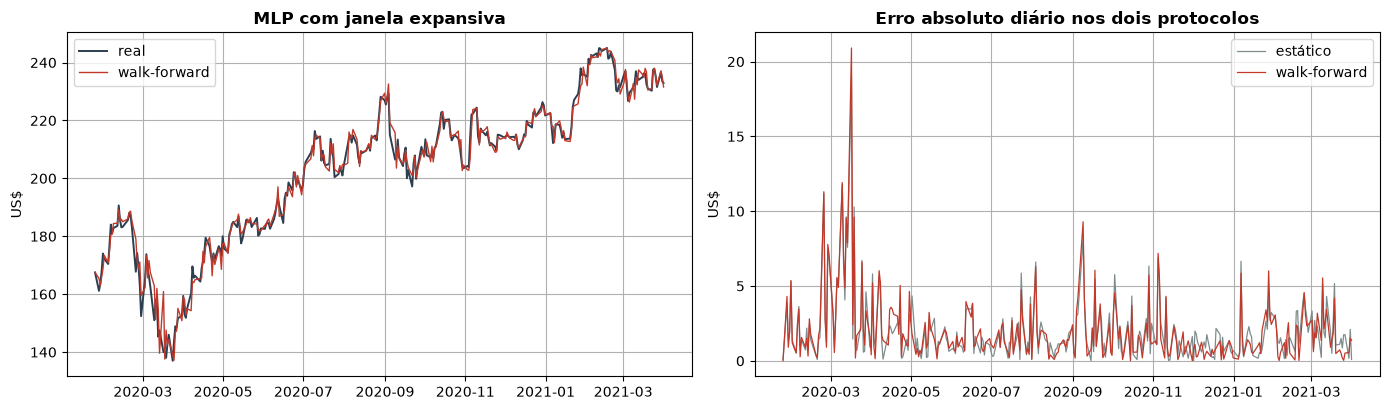

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].plot(wf_datas, wf_real, color="#2c3e50", lw=1.4, label="real")
axes[0].plot(wf_datas, wf_pred, color="#c0392b", lw=1.0, label="walk-forward")
axes[0].set_title("MLP com janela expansiva", weight="bold")
axes[0].set_ylabel("US$")
axes[0].legend()

axes[1].plot(wf_datas, np.abs(teste["y"].values - preco_pred_test), color="#7f8c8d",
             lw=0.9, label="estático")
axes[1].plot(wf_datas, np.abs(wf_real - wf_pred), color="#c0392b", lw=0.9,
             label="walk-forward")
axes[1].set_title("Erro absoluto diário nos dois protocolos", weight="bold")
axes[1].set_ylabel("US$")
axes[1].legend()

plt.tight_layout()
plt.show()

### Leitura

O retreino periódico melhorou o MLP de forma modesta, de US$ 2,0069 para US$ 1,9797,
cerca de 1,4%. Ainda assim a rede continua abaixo do benchmark do fechamento anterior,
que marca US$ 1,8996, com desvantagem de 4,22%.

A direção do efeito é o oposto da observada no Random Forest, que piorou sob o mesmo
protocolo. A diferença está em como cada família lida com valores extremos. A floresta
prevê pela média das folhas, então os dias de março de 2020 arrastam a previsão dos dias
comuns. A rede, com saída linear e regularização L2, absorve esses dias como pontos de
alavancagem sem reposicionar toda a função aprendida, e o histórico maior acaba ajudando
um pouco. É um ganho pequeno e não deve ser lido como superioridade: a rede partia de um
patamar pior e apenas encurtou a distância.

A leitura importante é outra e vale para os quatro notebooks. Modelos que recebem
variáveis defasadas como entrada são pouco sensíveis à troca de protocolo, porque já
operam em horizonte curto por construção, e nesse caso o walk-forward mede o efeito do
retreino, que pode ser positivo ou negativo. Modelos univariados, que precisam projetar a
própria série para frente, dependem inteiramente do protocolo: no horizonte fixo viram
uma reta e acumulam um erro que mede o tamanho da alta do ativo, enquanto sob
walk-forward voltam a ser competitivos. Comparar modelos de famílias diferentes sem
igualar o protocolo leva à conclusão errada.

Sobre o benchmark: nenhum dos dois modelos de aprendizado supera o fechamento do dia
anterior de forma consistente neste ativo. Isso não é falha de implementação, é o
resultado esperado em série de preço diário de ação líquida, em que a variação é
dominada por informação que não está no histórico de preços.

## 10. Curva de aprendizado: treino contra validação

O que se observa aqui é se a perda cai e quando ela estabiliza. Se a curva de treino continuasse
caindo enquanto a de validação subisse, seria sinal claro de overfitting, e o ponto onde as duas
se separam indicaria a época em que o early stopping deveria ter agido.

O `MLPRegressor` guarda a perda de treino em `loss_curve_` e o score de validação em
`validation_scores_`. Como estão em unidades diferentes, o gráfico usa dois painéis.

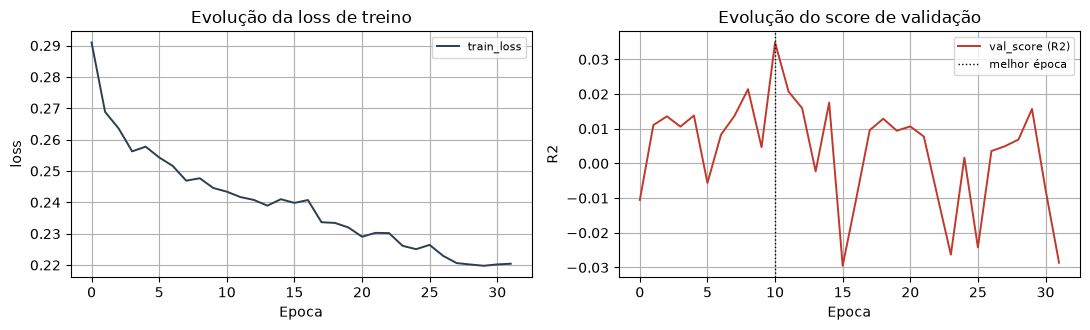

épocas executadas : 32 de 2000 definidas
melhor época      : 11
loss final        : 0.220421


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].plot(modelo.loss_curve_, color="#2c3e50", lw=1.4, label="train_loss")
axes[0].set_title("Evolução da loss de treino")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("loss")
axes[0].legend(fontsize=8)

axes[1].plot(modelo.validation_scores_, color="#c0392b", lw=1.4, label="val_score (R2)")
axes[1].axvline(int(np.argmax(modelo.validation_scores_)), color="black", ls=":", lw=1,
                label="melhor época")
axes[1].set_title("Evolução do score de validação")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("R2")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"épocas executadas : {modelo.n_iter_} de {modelo.max_iter} definidas")
print(f"melhor época      : {int(np.argmax(modelo.validation_scores_)) + 1}")
print(f"loss final        : {modelo.loss_curve_[-1]:,.6f}")

## 11. Real contra previsto

A diagonal é a reta y igual a x: quanto mais os pontos se colam nela, melhor o ajuste. Os limites
`mn` e `mx` consideram todos os pontos, reais e previstos, de treino e de teste, para que a
diagonal cubra todo o espalhamento do gráfico sem ficar curta nem ultrapassar a faixa dos dados.

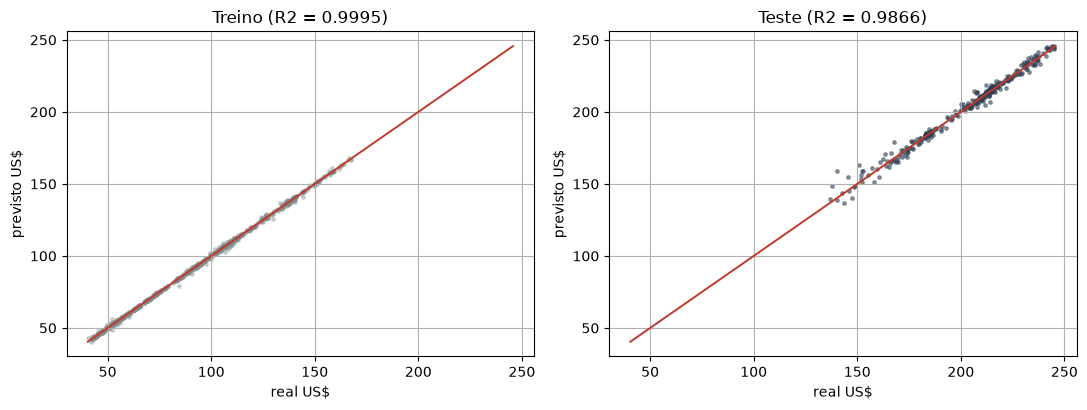

In [18]:
mn = min(treino["y"].min(), teste["y"].min(), preco_pred_train.min(), preco_pred_test.min())
mx = max(treino["y"].max(), teste["y"].max(), preco_pred_train.max(), preco_pred_test.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(treino["y"], preco_pred_train, s=6, alpha=0.35, color="#7f8c8d")
axes[0].plot([mn, mx], [mn, mx], color="#c0392b", lw=1.4)
axes[0].set_title(f"Treino (R2 = {m_train['R2']:,.4f})")
axes[0].set_xlabel("real US$")
axes[0].set_ylabel("previsto US$")

axes[1].scatter(teste["y"], preco_pred_test, s=6, alpha=0.5, color="#2c3e50")
axes[1].plot([mn, mx], [mn, mx], color="#c0392b", lw=1.4)
axes[1].set_title(f"Teste (R2 = {m_test['R2']:,.4f})")
axes[1].set_xlabel("real US$")
axes[1].set_ylabel("previsto US$")

plt.tight_layout()
plt.show()

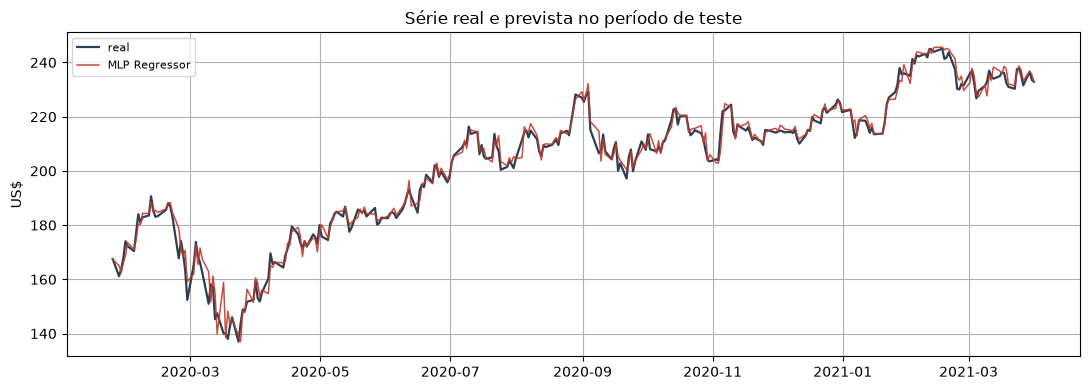

In [19]:
fig, ax = plt.subplots()
ax.plot(teste.index, teste["y"], color="#2c3e50", lw=1.6, label="real")
ax.plot(teste.index, preco_pred_test, color="#c0392b", lw=1.1, alpha=0.9, label="MLP Regressor")
ax.set_title("Série real e prevista no período de teste")
ax.set_ylabel("US$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12. Resíduos e histograma

Dois diagnósticos, exatamente os da aula.

O gráfico de resíduos contra previsto deve mostrar uma nuvem sem padrão em torno do zero. Se
aparecer um funil, com a dispersão crescendo conforme o valor previsto, isso indica que o erro
depende do nível do preço e o modelo está sistematicamente pior em alguma faixa.

O histograma deve estar centrado em zero e razoavelmente simétrico. Centro deslocado indica viés,
ou seja, o modelo erra sempre para o mesmo lado. Caudas muito longas indicam dias em que o modelo
falhou de forma grave.

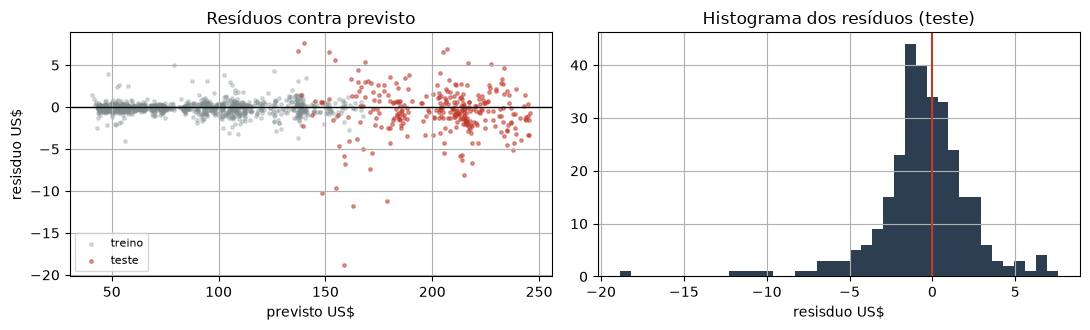

In [20]:
resid_train = treino["y"].values - preco_pred_train
resid_test  = teste["y"].values - preco_pred_test

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].scatter(preco_pred_train, resid_train, s=6, alpha=0.3, color="#7f8c8d", label="treino")
axes[0].scatter(preco_pred_test, resid_test, s=6, alpha=0.5, color="#c0392b", label="teste")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Resíduos contra previsto")
axes[0].set_xlabel("previsto US$")
axes[0].set_ylabel("resisduo US$")
axes[0].legend(fontsize=8)

axes[1].hist(resid_test, bins=40, color="#2c3e50")
axes[1].axvline(0, color="#c0392b", lw=1.5)
axes[1].set_title("Histograma dos resíduos (teste)")
axes[1].set_xlabel("resisduo US$")

plt.tight_layout()
plt.show()

In [21]:
pior = int(np.argmax(np.abs(resid_test)))
print(f"viés (erro médio no teste) : US$ {resid_test.mean():,.4f}")
print(f"desvio padrão do erro      : US$ {resid_test.std():,.4f}")
print(f"maior erro                 : US$ {np.abs(resid_test).max():,.4f} em {teste.index[pior]:%Y-%m-%d}")
print(f"erro médio no treino       : US$ {resid_train.mean():,.4f}")

viés (erro médio no teste) : US$ -0.5447
desvio padrão do erro      : US$ 2.8825
maior erro                 : US$ 18.8691 em 2020-03-16
erro médio no treino       : US$ -0.0931


## 13. Importância das variáveis

Rede neural não expõe importância de variável de forma direta como uma árvore. A alternativa é a
importância por permutação: embaralha-se uma coluna de cada vez no conjunto de teste e mede-se
quanto o MAE piora. Se embaralhar uma variável não muda nada, ela não estava sendo usada; se o
erro dispara, ela é decisiva.

O valor reportado é o aumento médio do erro em dez repetições de embaralhamento.

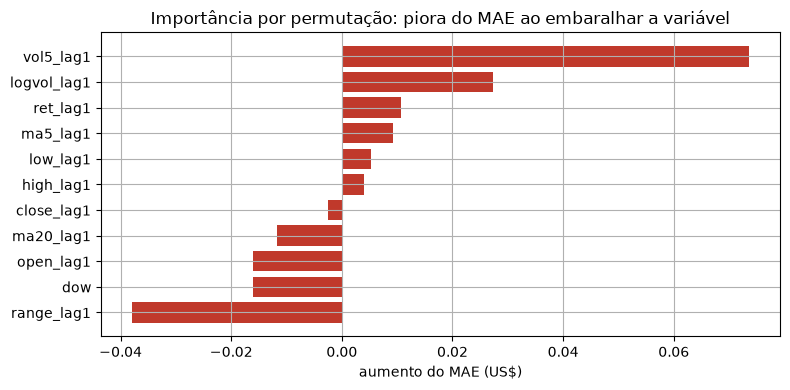

,piora_do_MAE
vol5_lag1,0.0736
logvol_lag1,0.0273
ret_lag1,0.0108
ma5_lag1,0.0093
low_lag1,0.0054
high_lag1,0.0039
close_lag1,-0.0025
ma20_lag1,-0.0117
open_lag1,-0.0160
dow,-0.0161


In [22]:
imp = permutation_importance(
    modelo,
    X_test_s,
    y_test.values,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=SEMENTE,
)

importancia = (
    pd.Series(imp.importances_mean, index=FEATURES)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancia.index, importancia.values, color="#c0392b")
ax.set_title("Importância por permutação: piora do MAE ao embaralhar a variável")
ax.set_xlabel("aumento do MAE (US$)")
plt.tight_layout()
plt.show()

importancia.sort_values(ascending=False).to_frame("piora_do_MAE")

## 14. Conclusões

1. O MLP só funciona nesse problema porque o alvo foi reformulado. Prevendo o nível do preço a
   rede ficaria presa na faixa vista no treino, entre US$ 40 e US$ 167, e o teste chega a US$ 245.
   Prevendo a variação em relação ao fechamento anterior, o alvo é estacionário e a faixa de
   treino cobre a de teste.

2. O escalonamento é obrigatório. As variáveis estão em ordens de grandeza muito distintas,
   `logvol_lag1` perto de 17 e `ret_lag1` perto de 0.001, e sem padronizar o otimizador fica
   dominado pelas colunas de maior escala.

3. O early stopping encerrou o treino na época 32, com a melhor época sendo a 11. Isso não é sinal
   de rede boa, é sinal de que não havia muito a aprender: a partir da época 11 o score de
   validação parou de melhorar.

4. O resultado honesto é que o MLP não bateu o benchmark. O MAE no teste foi US$ 2.0069 contra
   US$ 1.8996 da regra trivial de repetir o fechamento de ontem, uma piora de 5.65 por cento. O
   R2 de 0.9866 na escala de preço parece excelente, mas é enganoso: ele mede o acerto do nível,
   e o nível já vem quase pronto do `close_lag1` somado de volta. O que a rede precisava prever
   era a variação, e nessa escala o melhor score de validação foi 0.0349, ou seja, praticamente
   nenhuma capacidade preditiva.

5. Essa conclusão é coerente com a teoria e não um defeito da implementação. Em mercado líquido o
   preço de fechamento já incorpora a informação pública disponível, e a abertura do dia seguinte
   nasce muito perto dele. A variação residual é dominada por ruído, e nenhuma arquitetura de rede
   extrai sinal de onde não há. O Random Forest, com as mesmas variáveis, superou o benchmark em
   apenas 0.70 por cento, o que confirma o diagnóstico.

6. A importância por permutação reforça a leitura. As variáveis mais úteis são as de volatilidade
   e volume, `vol5_lag1` e `logvol_lag1`, e não as de nível de preço. Várias variáveis aparecem
   com piora negativa, isto é, embaralhá-las melhora o erro, o que caracteriza ruído e não sinal.